**1. DATA PROCESSING.**

**A. OBTAINING DATA.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**~IMPORTING LIBRARIES.**

In [ ]:
import numpy as np
import pandas as pd

**~LOAD AND READ THE DATASET.**

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/imdb_top_1000.csv')
print(df)

                                           Poster_Link  \
0    https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1    https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2    https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3    https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4    https://m.media-amazon.com/images/M/MV5BMWU4N2...   
..                                                 ...   
995  https://m.media-amazon.com/images/M/MV5BNGEwMT...   
996  https://m.media-amazon.com/images/M/MV5BODk3Yj...   
997  https://m.media-amazon.com/images/M/MV5BM2U3Yz...   
998  https://m.media-amazon.com/images/M/MV5BZTBmMj...   
999  https://m.media-amazon.com/images/M/MV5BMTY5OD...   

                 Series_Title Released_Year Certificate  Runtime  \
0    The Shawshank Redemption          1994           A  142 min   
1               The Godfather          1972           A  175 min   
2             The Dark Knight          2008          UA  152 min   
3      The Godfather: Part II  

**B. DATA CLEANING.**

In [ ]:
#Looking if any data is missing in movies
df.isnull().sum()

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [ ]:
#removing missing values
df.dropna(inplace=True)

In [ ]:
#Looking if there is any duplicate row
df.duplicated().sum()

0

**C. DATA MODIFICATION.**

In [ ]:
# Reindexing the movies in dataframe
df.reset_index(drop=True, inplace=True)

In [ ]:
# list of columns
list(df.columns)

['Poster_Link',
 'Series_Title',
 'Released_Year',
 'Certificate',
 'Runtime',
 'Genre',
 'IMDB_Rating',
 'Overview',
 'Meta_score',
 'Director',
 'Star1',
 'Star2',
 'Star3',
 'Star4',
 'No_of_Votes',
 'Gross']

In [ ]:
# replacing values
df['Certificate'].replace(['U', 'UA', 'A', 'R','PG','PG-13','Passed', 'Approved', 'TV-PG', 'U/A', 'GP', 'G'],
                        [1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1], inplace=True)

In [ ]:
print(df['Certificate'].unique())

[0 1]


In [ ]:
df['Runtime'] = df['Runtime'].replace(to_replace=r'([a-z/]+|[A-Z/]+)', value='', regex=True)
df.head(3)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,0,142,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,0,175,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,1,152,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"


In [ ]:
df['Runtime'] = df['Runtime'].astype(int)

In [ ]:
#convert categorical data i.e.status into numeric data
#df_Genre = pd.get_dummies(df['Genre'])
#df = pd.concat([df, df_Genre], axis=1)
#df.head(6)

In [ ]:
#iloc : When Index other than Numeric Value.
#df=df.iloc[:,:25]

**D. DATA VISUALIZATION.**

In [ ]:
#import the necessry libraries
import numpy as np
import matplotlib.pyplot as plt
from numpy import mean
from numpy import std
from numpy import cov
from numpy import corrcoef
from sklearn.feature_selection import SelectKBest
import seaborn as sns

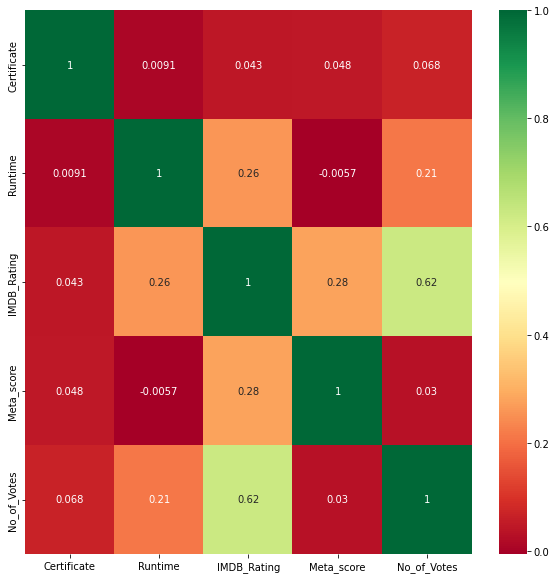

In [ ]:
#Importing Necessary Libraries.
import seaborn as sns
import matplotlib.pyplot as plt

#Get Correalation of Each Features in Dataset.
corrMatrix = df.corr()

top_corr_features = corrMatrix.index
plt.figure(figsize=(10,10))

#PlotHeatMap.
g= sns.heatmap(df[top_corr_features].corr(),annot=True,cmap="RdYlGn")

**E. FEATURE ENGINEERING.**

In [ ]:
#feature selection
f1=df.Meta_score
f2=df.No_of_Votes
y=df.Certificate
print(f1)
print(f2)
print(y)

0       80.0
1      100.0
2       84.0
3       90.0
4       96.0
       ...  
709     77.0
710     50.0
711     65.0
712     96.0
713     85.0
Name: Meta_score, Length: 714, dtype: float64
0      2343110
1      1620367
2      2303232
3      1129952
4       689845
        ...   
709      30144
710      45338
711     166409
712      40351
713      43374
Name: No_of_Votes, Length: 714, dtype: int64
0      0
1      0
2      1
3      0
4      1
      ..
709    0
710    1
711    1
712    1
713    1
Name: Certificate, Length: 714, dtype: int64


In [ ]:
#import the necessry libraries
from sklearn.feature_selection import SelectKBest

**2. BUILDING THE MODEL.**

**A. JUSTIFICATION OF THE SELECTED MODEL.**

**~Naive BayesAlgorithm.** : **We have used Naive Bayes Algorithm because we have More than one Variables in our Dataset**

**C. BUILDING THE MODEL.**

In [ ]:
#splitting training data and testing data
from sklearn.model_selection import train_test_split
x = pd.concat([f1,f2],axis=1)
y=df.Certificate
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=50)

In [ ]:
# training the model on training set
from sklearn.naive_bayes import GaussianNB
classifier=GaussianNB()
classifier.fit(x_train,y_train)

GaussianNB()

**3. MODEL EVALUATION.**

**A. JUSTIFICATION OF SELECTION OF MODEL PARAMETRS.**

**1.** **Precision Measures** How Good Our Model is when the **Prediction** is **Positive.** [ **Positive Value = 1**].

**2.** **Precision** Refers to the **Percentage** of Your **Results** Which are **Relevant.**

**3.** The **Ability** of a **Classification Model** to Identify Only The **Relevant Data Points.** Mathematically, **Precision** the Number of **True Positives Divided** by the Number of **True Positives** Plus the Number Of **False Positives.**

**B. PARAMETER CALCULATION.**

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [ ]:
# making predictions on the testing set
y_pred = classifier.predict(x_test)

In [ ]:
from sklearn import metrics
print("Gaussian Naive Bayes Model Accuracy [ In % ] : " , metrics.accuracy_score(y_test, y_pred)*100)

Gaussian Naive Bayes Model Accuracy [ In % ] :  58.74125874125874


In [ ]:
CM = confusion_matrix(y_test,y_pred)
AS = accuracy_score(y_test,y_pred)

In [ ]:
CM

array([[52, 22],
       [37, 32]])

In [ ]:
AS

0.5874125874125874

In [ ]:
# Finding precision
from sklearn.metrics import precision_score
precision_score(y_test, y_pred)

0.5925925925925926

In [ ]:
# To compute the F1 score, simply call the f1_score() function
from sklearn.metrics import f1_score
f1_score(y_test, y_pred)

0.5203252032520325

In [ ]:
from sklearn.metrics import recall_score
recall_score(y_test, y_pred)

0.463768115942029